# Chapter 12 - PCA Exercises

Nguyễn Phúc Minh Châu - 22302421

In [16]:
#import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_wine
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import KMeans
import time

## 1. Reducing the dimensionality of the Wine dataset to 2D

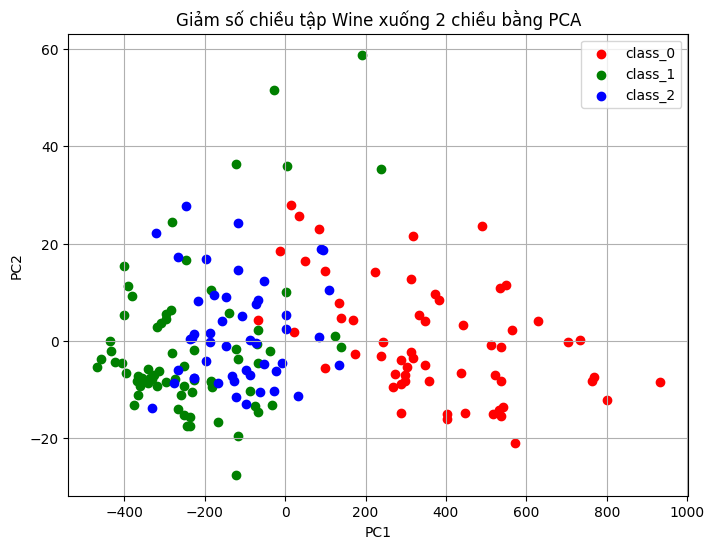

In [4]:
#load dataset
wine = load_wine()
X = wine.data
y = wine.target
target_names = wine.target_names

# Dùng PCA giảm số chiều xuống 2
pca = PCA(n_components=2)
X_r = pca.fit(X).transform(X)

#Vẽ Plot
plt.figure(figsize=(8, 6))

colors = ['red', 'green', 'blue']  # Màu cho 3 lớp
for color, i, target_names in zip(colors, [0, 1, 2], target_names):
    plt.scatter(X_r[y == i, 0], X_r[y == i, 1], color=color, label=target_names)

plt.title("Giảm số chiều tập Wine xuống 2 chiều bằng PCA")
plt.xlabel("PC1")  # Thành phần chính 1
plt.ylabel("PC2")  # Thành phần chính 2
plt.legend()
plt.grid(True)
plt.show()

## 2. Reducing the dimensionality of the Wine dataset to 3D

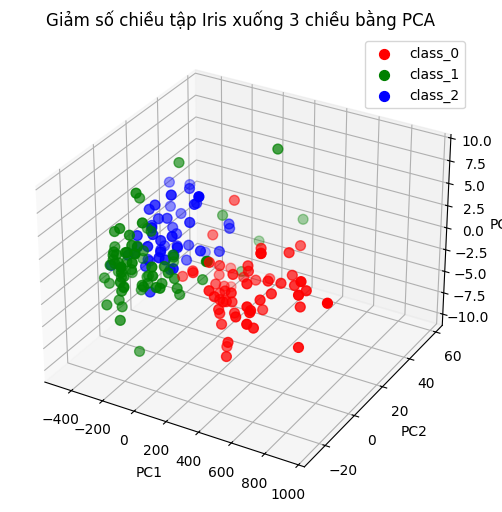

In [9]:
# Giảm dữ liệu Wine (đã có bên trên) xuống 3 chiều
pca = PCA(n_components=3)  # Giảm xuống 3 chiều
X_r = pca.fit_transform(X)  # Chiếu dữ liệu xuống 3 chiều

# Vẽ Plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')  # Khởi tạo biểu đồ 3D

colors = ['red', 'green', 'blue']  # Màu cho 3 lớp
for color, i, target_name in zip(colors, [0, 1, 2], target_names):
    ax.scatter(X_r[y == i, 0], X_r[y == i, 1], X_r[y == i, 2],
               color=color, label=target_name, s=50)  # s=50 là kích thước điểm

# Thiết lập nhãn trục
ax.set_title("Giảm số chiều tập Iris xuống 3 chiều bằng PCA")
ax.set_xlabel("PC1")  # Thành phần chính 1
ax.set_ylabel("PC2")  # Thành phần chính 2
ax.set_zlabel("PC3")  # Thành phần chính 3

ax.legend()
plt.show()

## 3. Determine the smallest k such that the cumulative explained variance is >= 90% on the Wine dataset.

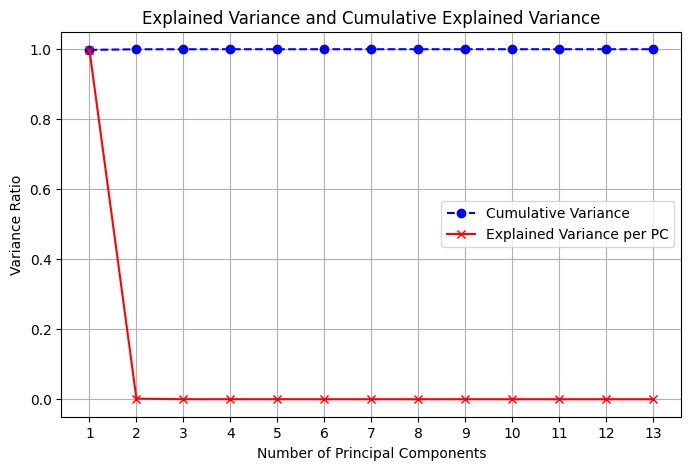


 Number of PCs k to retain (>=90% variance): 1


In [11]:
# Áp dụng PCA
pca = PCA()
pca.fit(X)

# Lấy explained variance ratio và cumulative variance
explained_variance_ratio = pca.explained_variance_ratio_  # Tỷ lệ phương sai được giải thích bởi từng thành phần chính
cumulative_variance = np.cumsum(explained_variance_ratio)  # Phương sai tích lũy (cộng dồn)

# Vẽ biểu đồ explained variance và cumulative variance
plt.figure(figsize=(8,5))

# Vẽ cumulative variance (phương sai tích lũy) với marker 'o' và đường nét '--' màu xanh dương
plt.plot(range(1, len(explained_variance_ratio)+1), cumulative_variance,
         marker='o', linestyle='--', color='b')

# Vẽ explained variance của từng PC với marker 'x' và đường nét '-' màu đỏ
plt.plot(range(1, len(explained_variance_ratio)+1), explained_variance_ratio,
         marker='x', linestyle='-', color='r')

plt.title('Explained Variance and Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')  # Trục X: số thành phần chính
plt.ylabel('Variance Ratio')                  # Trục Y: tỷ lệ phương sai
plt.xticks(range(1, len(explained_variance_ratio)+1))  # Đánh số các PC trên trục X
plt.grid(True)
plt.legend(['Cumulative Variance', 'Explained Variance per PC'])  # Chú thích
plt.show()

# Lựa chọn số PC tối ưu tại điểm "elbow"sao cho cumulative_variance >= 0.9 (giải thích >=90% phương sai)
num_pc_optimal = np.argmax(cumulative_variance >= 0.9) + 1
print(f"\n Number of PCs k to retain (>=90% variance): {num_pc_optimal}")

## 4. Measure the time it takes to cluster the Wine dataset into 5 clusters.

In [35]:
wine = load_wine()
X = wine.data

n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10) # Set n_init to suppress warning

start_time = time.time()
kmeans.fit(X)
end_time = time.time()

clustering_time = end_time - start_time
print(f"Time taken to cluster the Wine dataset ({X.shape[1]} dims) into {n_clusters} clusters: {clustering_time:.4f} seconds")

Time taken to cluster the Wine dataset (13 dims) into 5 clusters: 0.0322 seconds


## 5. Measure the time it takes to cluster the Wine dataset, after it has been reduced to k dimensions (k was determined in exercise 3), into 5 clusters.

In [36]:
wine = load_wine()
X = wine.data
pca = PCA(n_components=1)
X_r = pca.fit(X).transform(X)

n_clusters = 5
kmeans_reduced = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)

start_time_reduced = time.time()
kmeans_reduced.fit(X_r)
end_time_reduced = time.time()

clustering_time_reduced = end_time_reduced - start_time_reduced
print(f"Time taken to cluster the reduced Wine dataset ({X_r.shape[1]} dims) into {n_clusters} clusters: {clustering_time_reduced:.4f} seconds")

Time taken to cluster the reduced Wine dataset (1 dims) into 5 clusters: 0.0142 seconds


## 6. Give your comments based on the results of exercises 4 and 5.

Based on the results of exercises 4 and 5, we can make the following comments:

In exercise 4:

- The clustering time for the original Wine dataset (13 dimensions) into 5 clusters was 0.0322 seconds.

In exercise 5:
- The clustering time for the PCA-reduced Wine dataset (1 dimension) into 5 clusters was 0.0142 seconds.

Reducing the dimensionality of the Wine dataset from 13 features to just 1 principal component using PCA significantly decreased the time required to perform K-Means clustering. The clustering time was reduced by more than half (from 0.0322 seconds to 0.0142 seconds).

This demonstrates that PCA can be an effective technique for improving the computational efficiency of clustering algorithms by working with a lower-dimensional representation of the data, especially when dealing with high-dimensional datasets.